In [6]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm
import pickle

from pydub import AudioSegment
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import itertools

import warnings
warnings.filterwarnings("ignore")

In [7]:
ds_train = pd.read_csv('./data/chunks_specie_sample_train.csv')
ds_test = pd.read_csv('./data/chunks_specie_sample_test.csv')
ds_val = pd.read_csv('./data/chunks_specie_sample_val.csv')
ds_train = ds_train[['audio_path', 'label']]
ds_test = ds_test[['audio_path', 'label']]
ds_val = ds_val[['audio_path', 'label']]
print(ds_train.shape)
print(ds_test.shape)
print(ds_val.shape)
ds_train.sample(5)

(12730, 2)
(2674, 2)
(6292, 2)


,audio_path,label
5862,chunks/251661_chunk50.mp3,Troglodytes aedon
5315,chunks/498638_chunk23.mp3,Troglodytes aedon
1451,chunks/221134_chunk16.mp3,Cistothorus platensis
12341,chunks/571574_chunk7.mp3,Cistothorus apolinari
7442,chunks/443226_chunk2.mp3,Troglodytes aedon


In [8]:
#ds_train = ds_train[ds_train['audio_path'] != 'chunks/337985_chunk40.mp3']
#ds_train.reset_index(drop=True, inplace=True)

# guardar los datasets
#ds_train.to_csv('/Users/camcortes/Documents/birds-sounds/data/chunks_specie_sample_train.csv', index=False)

In [9]:
# label encoder
le = LabelEncoder()
ds_train['label'] = le.fit_transform(ds_train['label'])
ds_test['label'] = le.transform(ds_test['label'])
ds_val['label'] = le.transform(ds_val['label'])

In [10]:
etiquetas = ds_train['label']
clases, conteo_clases = np.unique(etiquetas, return_counts=True)
weight = dict(zip(clases, np.max(conteo_clases) / conteo_clases))

In [11]:
X = ds_train['audio_path']
y = ds_train['label']

X_test = ds_test['audio_path']
y_test = ds_test['label']

X_val = ds_val['audio_path']
y_val = ds_val['label']

In [12]:
num_clases = y.nunique()
print(num_clases)

9


In [13]:
#getting mfcc features for all the data points in test and train

def get_mfcc(path):
    """
    Extracts MFCC (Mel-frequency cepstral coefficients) features from an audio file.
    
    Parameters:
    path (str): The file path to the audio file.
    
    Returns:
    numpy.ndarray: A 2D array where each row corresponds to the MFCC features of a frame.
    """
    y, sr = librosa.load(path, sr=None, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=10000)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    return mfccs.T

In [14]:
def process_audio_files(X, y):
    """
    Processes a list of audio file paths to extract MFCC features and resize them.
    
    Args:
        X (pd.Series): A pandas Series containing paths to audio files.
        y (pd.Series): A pandas Series containing labels corresponding to the audio files.
        
    Returns:
        tuple: A tuple containing:
            - X_processed (np.ndarray): A numpy array of processed MFCC features with shape (num_files, 65, 40).
            - y_processed (np.ndarray): A numpy array of labels corresponding to the audio files.
    """
    temp = []
    label = []
    
    for i in tqdm(range(len(X))):
        audio_path = X.iloc[i]
        mfcc = get_mfcc(audio_path)
        mfcc = np.resize(mfcc, (65, 40,))
        temp.append(mfcc)
        label.append(y.iloc[i])
        
    X_processed = np.asarray(temp)
    y_processed = np.asarray(label)
    
    return X_processed, y_processed

In [15]:
#%%time
X_processed, y = process_audio_files(X, y)
X_test_processed, y_test = process_audio_files(X_test, y_test)
X_val_processed, y_val = process_audio_files(X_val, y_val)

100%|██████████| 6292/6292 [03:29<00:00, 30.09it/s]


In [16]:
with open('X_processed.pkl', 'wb') as f:
    pickle.dump(X_processed, f)
    
with open('y_train.pkl', 'wb') as f:
    pickle.dump(y, f)

with open('X_test_processed.pkl', 'wb') as f:
    pickle.dump(X_test_processed, f)
    
with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)
    
with open('X_val_processed.pkl', 'wb') as f:
    pickle.dump(X_val_processed, f)
    
with open('y_val.pkl', 'wb') as f:
    pickle.dump(y_val, f)

In [4]:
with open('X_processed.pkl', 'rb') as f:
    X_processed = pickle.load(f)

with open('y_train.pkl', 'rb') as f:
    y = pickle.load(f)

with open('X_test_processed.pkl', 'rb') as f:
    X_test_processed = pickle.load(f)
    
with open('y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)

with open('X_val_processed.pkl', 'rb') as f:
    X_test_processed = pickle.load(f)
    
with open('y_val.pkl', 'rb') as f:
    y_test = pickle.load(f)

In [17]:
print(f'El conjunto de entrenamiento tiene la forma {X_processed.shape}')
print(f'Los labels del conjunto de entrenamiento tiene la forma {y.shape}')

El conjunto de entrenamiento tiene la forma (12730, 65, 40)
Los labels del conjunto de entrenamiento tiene la forma (12730,)


## **Modelo**

In [18]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import keras.backend as K

tf.keras.backend.clear_session()

In [19]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [20]:
print(tf.config.list_physical_devices('GPU'))

[]


In [21]:
# Capa de entrada
input_layer = layers.Input(shape=(65, 40), name='input_layer')

# Bloque convolucional 1
x = layers.Conv1D(filters=64, kernel_size=6, padding='same')(input_layer)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=128, kernel_size=9, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Bloque convolucional 2
x = layers.Conv1D(filters=128, kernel_size=9, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=256, kernel_size=12, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Bloque convolucional 3
x = layers.Conv1D(filters=256, kernel_size=12, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv1D(filters=256, kernel_size=15, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

# Capas LSTM bidireccionales
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
x = layers.Dropout(0.5)(x)

# Capas densas
x = layers.Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer='l2')(x)
x = layers.Dropout(0.5)(x)

# Capa de salida
output_layer = layers.Dense(num_clases, activation='softmax', name='output_layer')(x)

# Creación del modelo
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 65, 40)]          0         
                                                                 
 conv1d (Conv1D)             (None, 65, 64)            15424     
                                                                 
 batch_normalization (BatchN  (None, 65, 64)           256       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 65, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 65, 128)           73856     
                                                                 
 batch_normalization_1 (Batc  (None, 65, 128)          512       
 hNormalization)                                             

In [22]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_weights_mfcc.keras',  
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_weights_only=False,  # guardar solo los pesos
    save_best_only=True,     # guardar solo el mejor modelo
)

# Callback para TensorBoard
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='logs',
    histogram_freq=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=15, 
    min_lr=0.00001)

# Callback para EarlyStopping
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    mode='min'
)

callbacks = [checkpoint_cb, tensorboard_cb, early_callback, reduce_lr]

In [23]:
#model.load_weights('model_weights_mfcc-v3.weights.h5')

# Paso 3: Compilar el modelo (opcional)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
#compile
ls = tf.keras.losses.SparseCategoricalCrossentropy()
adam = tf.keras.optimizers.Adam()
model.compile(adam, ls, metrics=['accuracy'])

history = model.fit(X_processed, y, 
                    validation_data=(X_val_processed, y_val),
                    callbacks=callbacks,
                    epochs=1000,
                    batch_size=16,
                    class_weight=weight)

796/796 [==============================] - ETA: 0s - loss: 2.9834 - accuracy: 0.4976
Epoch 121: val_loss did not improve from 2.07368
796/796 [==============================] - 90s 112ms/step - loss: 2.9834 - accuracy: 0.4976 - val_loss: 2.1330 - val_accuracy: 0.3406 - lr: 1.0000e-05
Epoch 122/1000
796/796 [==============================] - ETA: 0s - loss: 3.1932 - accuracy: 0.4909
Epoch 122: val_loss did not improve from 2.07368
796/796 [==============================] - 88s 111ms/step - loss: 3.1932 - accuracy: 0.4909 - val_loss: 2.1159 - val_accuracy: 0.3471 - lr: 1.0000e-05
Epoch 123/1000
796/796 [==============================] - ETA: 0s - loss: 3.0211 - accuracy: 0.4929
Epoch 123: val_loss did not improve from 2.07368
796/796 [==============================] - 87s 109ms/step - loss: 3.0211 - accuracy: 0.4929 - val_loss: 2.1112 - val_accuracy: 0.3511 - lr: 1.0000e-05
Epoch 124/1000
796/796 [==============================] - ETA: 0s - loss: 3.1134 - accuracy: 0.4900
Epoch 124: val_

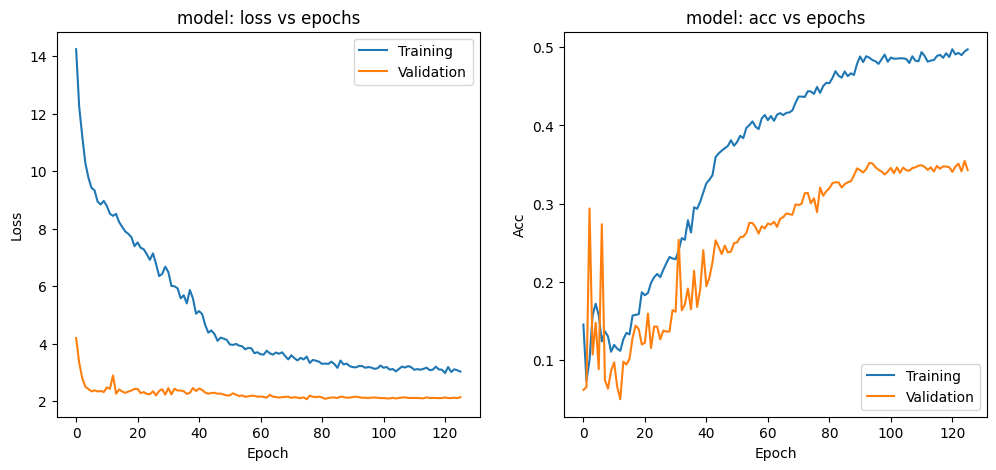

In [25]:
fig = plt.figure(figsize=(12, 5))
fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model: loss vs epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## **Predicción**

In [ ]:
#carga el modelo model_weights_mfcc
model = tf.keras.models.load_model('model_weights_mfcc.keras')

In [26]:
preds = model.predict(X_test_processed)
model.evaluate(X_test_processed, y_test)

84/84 [==============================] - 3s 32ms/step - loss: 2.1975 - accuracy: 0.3257


[2.1975369453430176, 0.32572925090789795]

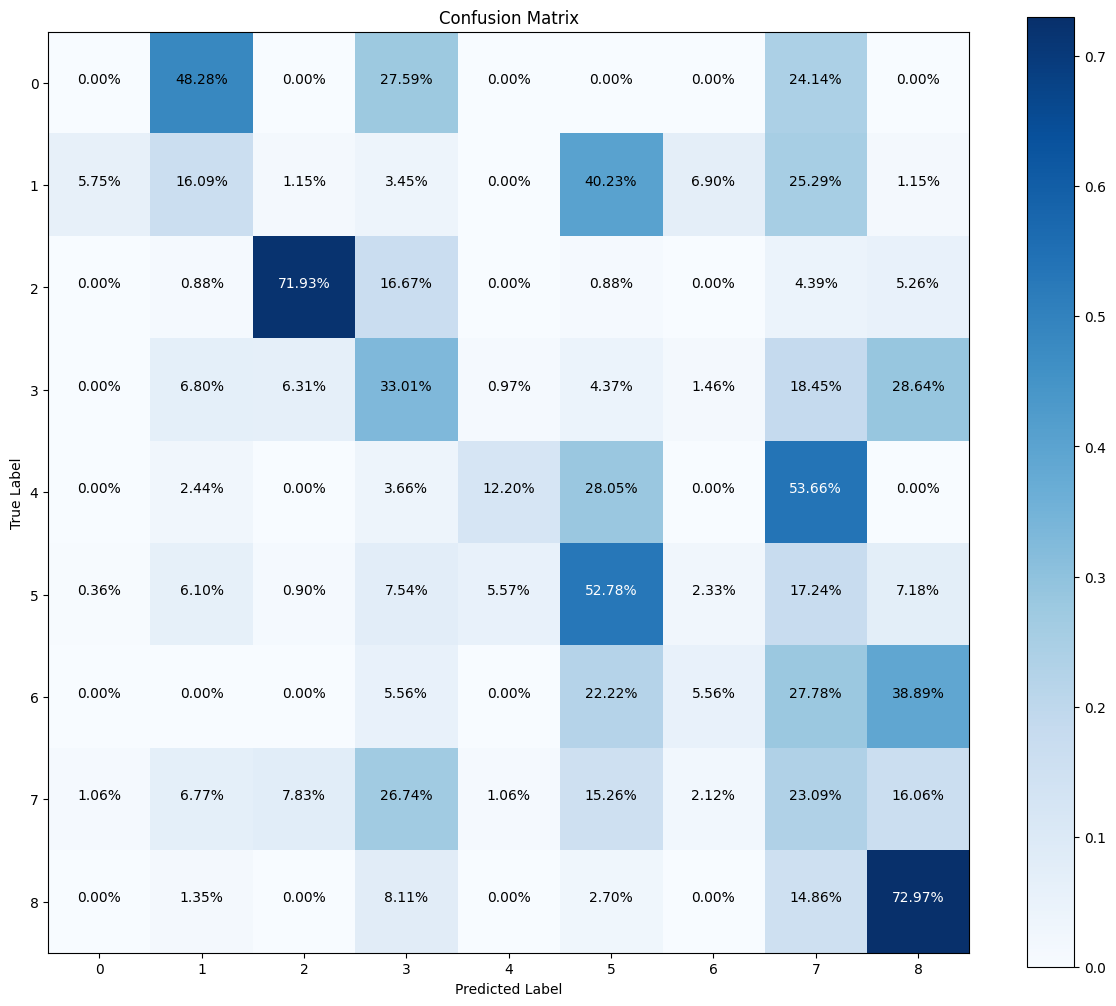

In [28]:
cm = confusion_matrix(y_test, np.argmax(preds, axis=1))

# Número de clases
num_classes = cm.shape[0]

# Normalizar la matriz de confusión
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Graficar
plt.figure(figsize=(12, 10))  # Opcional, para ajustar el tamaño de la figura
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes), rotation=0)
plt.yticks(tick_marks, range(num_classes))

# Anotar la matriz
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2%}",
             horizontalalignment="center",
             color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Guardar la figura en formato PDF
plt.savefig('confusion_matrix.pdf', format='pdf')
plt.show()

In [29]:
accuracy_score(y_test, np.argmax(preds, axis=1))

0.3257292445774121

In [30]:
#codificar las etiquetas
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(np.argmax(preds, axis=1))

In [31]:
print(classification_report(y_test_labels, y_pred_labels))

                              precision    recall  f1-score   support

Campylorhynchus albobrunneus       0.00      0.00      0.00        29
     Campylorhynchus zonatus       0.08      0.16      0.10        87
       Cistothorus apolinari       0.37      0.72      0.49       114
       Cistothorus platensis       0.12      0.33      0.18       206
        Microcerculus bambla       0.17      0.12      0.14        82
    Microcerculus marginatus       0.49      0.53      0.51       557
     Odontorchilus branickii       0.02      0.06      0.03        18
           Troglodytes aedon       0.60      0.23      0.33      1507
    Troglodytes solstitialis       0.13      0.73      0.22        74

                    accuracy                           0.33      2674
                   macro avg       0.22      0.32      0.22      2674
                weighted avg       0.48      0.33      0.34      2674

